In [1]:
import xarray_batcher as xb


/home/n/nath/nobackups/miniforge3/envs/torch_24/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
truth_batch=1
assert truth_batch is not None

In [ ]:

dl = xb.DataModule()


In [ ]:

for d in dl.train_dataloader():
    print(d)
    break


In [2]:
from xarray_batcher.get_fcst_and_truth import get_all, stream_ifs
import numpy as np

In [3]:
truth_ds = get_all([2018],model='truth',batch_type="24-hourly",use_climatology=False,log_precip=False)

Only getting truth values over, 372 dates
Using log precip of False


100%|███████████████████████████████████████████████████████████████████████████████████████| 372/372 [00:12<00:00, 30.89it/s]


Finished retrieving truth values in ---- 12.35961127281189 s---- for years [2018]


In [4]:
from xarray_batcher.loading import load_hires_constants

constants = load_hires_constants(1)

In [5]:
import importlib
importlib.reload(xb)

batch_size=[1,128,128]

data_generator = xb.StreamDataset(truth_ds,['cp','mcc', 'sp', 'ssr', 't2m', 'tciw', 'tclw', 'tcrw', 'tcw', 'tcwv', 'tp', 'u700', 'v700'],
                                  constants,batch_size=batch_size,batch_type="24-hourly",prefetch=False)


In [6]:
%%time

data = data_generator.__sample__(n_samp=2)

/home/n/nath/nobackups/miniforge3/envs/torch_24/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42117 instead
  warnings.warn(


modified files in --- 22.871183156967163 s---


2025-12-04 11:34:20,215 - distributed.core - INFO - Connection to tcp://127.0.0.1:43143 has been closed.
2025-12-04 11:34:20,218 - distributed.core - INFO - Connection to tcp://127.0.0.1:43143 has been closed.
2025-12-04 11:34:20,218 - distributed.core - INFO - Connection to tcp://127.0.0.1:43143 has been closed.
2025-12-04 11:34:20,218 - distributed.core - INFO - Connection to tcp://127.0.0.1:43143 has been closed.
2025-12-04 11:34:20,219 - distributed.core - INFO - Connection to tcp://127.0.0.1:43143 has been closed.


CPU times: user 20 s, sys: 1.74 s, total: 21.7 s
Wall time: 27.8 s


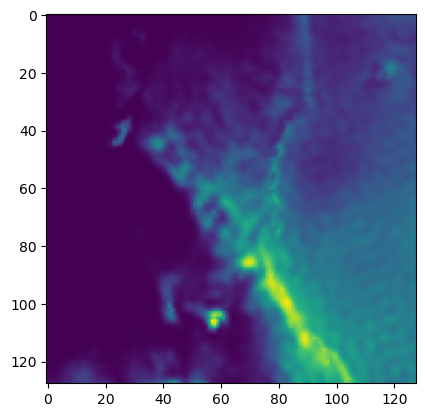

In [12]:
import matplotlib.pyplot as plt

plt.imshow(data[0][0][0,:,:,20])

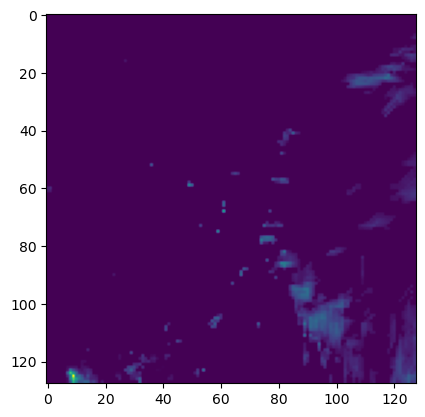

In [13]:
plt.imshow(data[0][1][0,:,:])

In [8]:
%%time

X,y = next(data_generator.__iter__())

CPU times: user 25 μs, sys: 6 μs, total: 31 μs
Wall time: 36 μs


In [9]:
X.shape

torch.Size([1, 128, 128, 54])

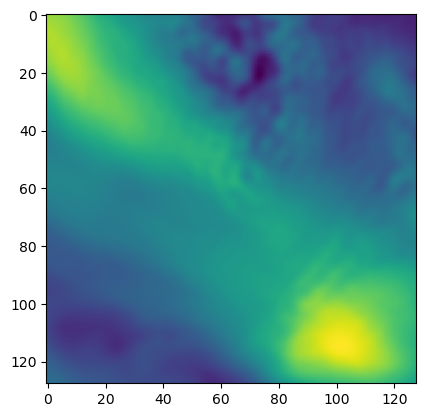

In [11]:
import matplotlib.pyplot as plt

plt.imshow(X[0,:,:,-4])

           

In [12]:
np.unique(X[0,:,:,3])

array([-3.9511278], dtype=float32)

In [ ]:
import xbatcher
batch_size=[1,128,128]
y_generator = xbatcher.BatchGenerator(
            truth_ds,
            {"time": batch_size[0], "lat": batch_size[1], "lon": batch_size[2]},
            input_overlap={
                "lat": int(batch_size[1] / 32),
                "lon": int(batch_size[2] / 32),
            },
        )

In [ ]:
%%time

f, c = get_all([2018],model='ifs',truth_batch=[y_generator[0],y_generator[1]],stream=True,offset=24,
        variables=['cp', 'u700', 'tp'],batch_type="24-hourly")



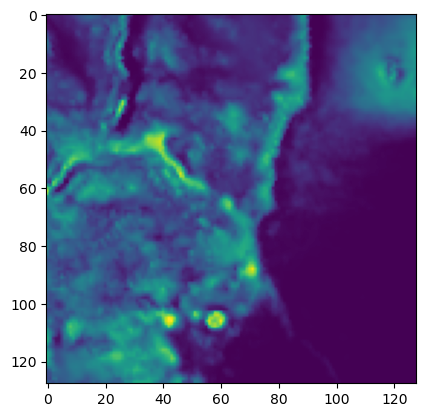

In [13]:
import matplotlib.pyplot as plt

plt.imshow(f[0][0].cp.values[1,:,:,0])

           

In [9]:
workers = list(c.scheduler_info()['workers'])
c.retire_workers(workers=workers, close_workers=True)
c.shutdown()

2025-10-30 21:36:04,004 - distributed.core - INFO - Connection to tcp://127.0.0.1:37483 has been closed.
2025-10-30 21:36:04,005 - distributed.core - INFO - Connection to tcp://127.0.0.1:37483 has been closed.
2025-10-30 21:36:04,020 - distributed.core - INFO - Connection to tcp://127.0.0.1:37483 has been closed.
2025-10-30 21:36:04,038 - distributed.core - INFO - Connection to tcp://127.0.0.1:37483 has been closed.
2025-10-30 21:36:04,039 - distributed.core - INFO - Connection to tcp://127.0.0.1:37483 has been closed.


<xarray.Dataset> Size: 8MB
Dimensions:          (time: 2, valid_time: 29, latitude: 128, longitude: 128)
Coordinates:
  * time             (time) datetime64[ns] 16B 2018-01-01 2018-01-01
  * latitude         (latitude) int64 1kB 0 1 2 3 4 5 ... 123 124 125 126 127
  * longitude        (longitude) int64 1kB 0 1 2 3 4 5 ... 123 124 125 126 127
Dimensions without coordinates: valid_time
Data variables:
    fcst_valid_time  (time, valid_time) datetime64[ns] 464B 2018-01-01 ... 20...
    tp_mean          (time, valid_time, latitude, longitude) float32 4MB 0.00...
    tp_sd            (time, valid_time, latitude, longitude) float32 4MB 0.00...
Attributes:
    description:  IFS forecast ensemble mean and standard deviation in the IC...
[[[[[1.18101062e-03 3.86462756e-03 0.00000000e+00 0.00000000e+00]
    [1.17205107e-03 3.81277432e-03 0.00000000e+00 0.00000000e+00]
    [1.08824763e-03 3.63614224e-03 0.00000000e+00 0.00000000e+00]
    ...
    [1.43755926e-04 6.05133642e-03 0.00000000e+00 0.000

In [23]:
y_generator[1]

<xarray.Dataset> Size: 83kB
Dimensions:        (time: 1, lat: 128, lon: 128)
Coordinates:
  * lon            (lon) float32 512B 31.55 31.65 31.75 ... 44.05 44.15 44.25
  * lat            (lat) float32 512B -13.65 -13.55 -13.45 ... -1.15 -1.05 -0.95
  * time           (time) datetime64[ns] 8B 2018-01-02T06:00:00
Data variables:
    precipitation  (time, lat, lon) float32 66kB 1.613 1.635 ... -0.02173
    mask           (time, lat, lon) bool 16kB False False False ... False False
Attributes:
    description:  24h average of IMERG V07 rainfall data in the ICPAC region

In [1]:
from xarray_batcher.create_npz import TruthDataloader_to_Npz
import numpy as np

reg_dict = TruthDataloader_to_Npz('/network/group/aopp/predict/AWH026_NATH_GFSAIMOD/NeuralProcess/',years=[2023, 2024],months=np.arange(1,11).tolist())


/home/n/nath/nobackups/miniforge3/envs/torch_24/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|                                                                                      | 11/14592 [00:00<02:22, 102.45it/s]

[ 1  2  3  4  5  6  7  8  9 10 11]


100%|████████████████████████████████████████████████████████████████████████████████████| 14592/14592 [14:08<00:00, 17.21it/s]


Finished loading in IMERG data in ----848.05 s-----


  0%|                                                                                        | 3/14640 [00:00<08:25, 28.97it/s]

[ 1  2  3  4  5  6  7  8  9 10 11]


100%|████████████████████████████████████████████████████████████████████████████████████| 14640/14640 [04:57<00:00, 49.20it/s]


Finished loading in IMERG data in ----297.56 s-----


In [2]:
## Save forecasts as zarr
import glob
import xarray as xr
import os
from tqdm import tqdm

in_path = "/network/group/aopp/predict/AWH024_COOPERNATH_IFS/IFS/IFS-regICPAC-meansd/"
out_path = "/network/group/aopp/predict/AWH024_COOPERNATH_IFS/cGAN_gefs/zarr/"

for year in [2021]:

    if not os.path.exists(out_path+f'{year}/'):
        os.makedirs(out_path+f'{year}/')

    year_path = in_path+f"{year}/"
    files = glob.glob(year_path+"*.nc")
    var = [f.split('/')[-1].split('.nc')[0] for f in files]
    for v,file in tqdm(zip(var,files),total=len(files)):
        d = xr.open_dataset(file)
        d.chunk({'time':1,'latitude':-1,'longitude':-1})
        if os.path.exists(out_path+f'{v}_2021.zarr'):
            d.to_zarr(out_path+f'{v}_2021.zarr',mode='a-',append_dim='time')
        else:
            d.to_zarr(out_path+f'{v}_2021.zarr',mode='w')
        



100%|██████████████████████████████████████████████████████████████████████████████████████| 14/14 [1:12:31<00:00, 310.79s/it]


In [5]:
from datetime import datetime

datetime.now().strftime("%Y%M%d")

'20252231'